In [59]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    
)

from langdetect import detect_langs
from textblob import TextBlob
from wordcloud import WordCloud


In [12]:
text = 'I hate vietnam'
detect_langs(text)

[sv:0.4285715211086784, af:0.2857148162610883, en:0.2857122144566411]

In [15]:
valence = TextBlob(text)
valence.sentiment

Sentiment(polarity=-0.8, subjectivity=0.9)

In [19]:
movie_reviews = pd.read_csv("data/IMDB Dataset.csv")

In [21]:
movie_reviews.sample(5)

,review,sentiment
31726,Horses on Mars is a wonderful journey taken by...,positive
2630,This is a typical Sandra Bullock movie in whic...,positive
37602,"This film was a waste of time, even rented on ...",negative
35645,The premise of this anime series is about brea...,positive
30497,"""Live Together, Die Alone"" is divided into thr...",positive


In [22]:
movie_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
movie_reviews.sentiment.value_counts

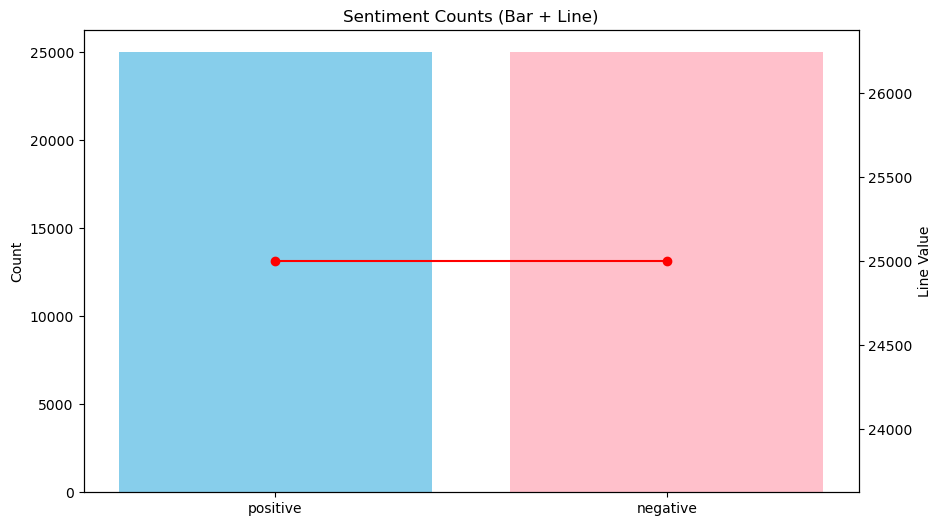

In [76]:
fig, ax1 = plt.subplots(figsize=(10,6))

sentiment_counts = movie_reviews['sentiment'].value_counts()

# Bar chart
ax1.bar(sentiment_counts.index, sentiment_counts.values, color=['skyblue','pink'])
ax1.set_ylabel("Count")

# Second axis
ax2 = ax1.twinx()
ax2.plot(sentiment_counts.index, sentiment_counts.values, color='red', marker='o')
ax2.set_ylabel("Line Value")

plt.title("Sentiment Counts (Bar + Line)")
plt.show()


In [26]:
length_review = movie_reviews.review.str.len()
print(length_review)

0        1761
1         998
2         926
3         748
4        1317
         ... 
49995    1008
49996     642
49997    1280
49998    1234
49999     678
Name: review, Length: 50000, dtype: int64


In [32]:
longest_review = max(length_review)
shortest_review = min(length_review)
print(f'The longest review is length: {longest_review} \nThe shortest review is length: {shortest_review}')

The longest review is length: 13704 
The shortest review is length: 32


In [ ]:
movie_reviews['sentiment'] = movie_reviews['sentiment'].map({'positive': 1, 'negative': 0})

In [35]:
X = movie_reviews['review']
y = movie_reviews['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.3, random_state= 42)

print('X train shape', X_train.shape)
print('y train shape', y_train.shape)
print('X test shape', X_test.shape)
print('y test shape', y_test.shape)

X train shape (35000,)
y train shape (35000,)
X test shape (15000,)
y test shape (15000,)


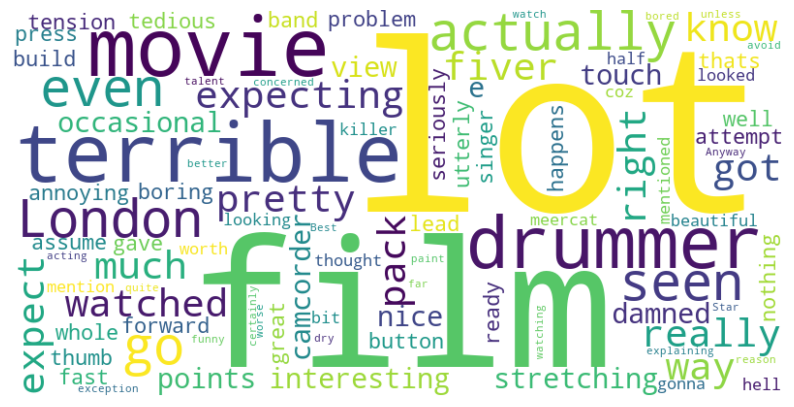

In [50]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(movie_reviews.review[34])

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()



In [60]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>","",text)
    return text

In [61]:
X_train = X_train.apply(clean_text)
X_test = X_test.apply(clean_text)

In [69]:
tfidf= TfidfVectorizer(
    max_features = 5000,
    stop_words = 'english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.fit_transform(X_test)

In [70]:
model= LogisticRegression()
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [71]:
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1] 

In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.59      0.59      0.59      7411
    positive       0.60      0.60      0.60      7589

    accuracy                           0.59     15000
   macro avg       0.59      0.59      0.59     15000
weighted avg       0.59      0.59      0.59     15000



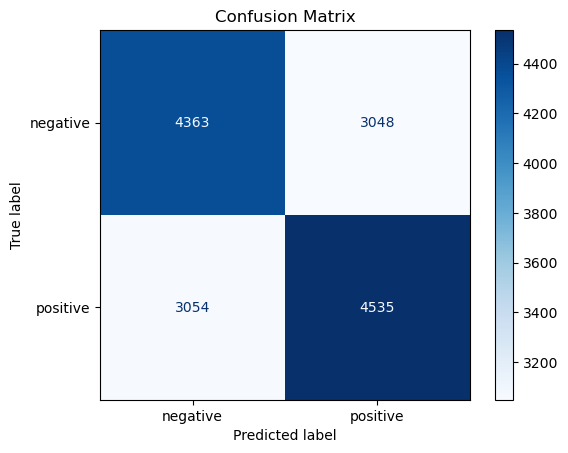

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
